# Kernel SVM v2 — Hierarchical + ADASYN + Full-Data Refit
**CS3244 Group 32 | Zakariyyaa Chachia**

Dataset : Smartphone-Based Recognition of Human Activities and Postural Transitions (UCI)

Improvements over v1:
- Hierarchical SVM: binary router → static specialist / transition specialist
- ADASYN oversampling (adaptive, focuses synthetics near decision boundaries)
- After hyperparameter tuning, final model refit on train+val combined
- Stratified train/val split
- AUC-ROC and MIoU reported

## Imports & Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import GridSearchCV, train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

DATA_PATH = "Data/"
VAL_SIZE  = 0.1

STATIC_CLASSES = np.array([1, 2, 3, 4, 5, 6])
TRANS_CLASSES  = np.array([7, 8, 9, 10, 11, 12])

# ADASYN target per minority class. ADASYN may generate slightly fewer
# than this value when density estimation reduces the count for some classes.
SMOTE_TARGET = 500

# Binary router: only classify as 'static' when confidence >= this threshold.
# Asymmetric because misrouting a transition to the static branch is guaranteed
# wrong (static SVM has never seen transition classes).
STATIC_THRESHOLD = 0.75

ACTIVITY_LABELS = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING",
    "STAND_TO_SIT", "SIT_TO_STAND", "SIT_TO_LIE",
    "LIE_TO_SIT", "STAND_TO_LIE", "LIE_TO_STAND"
]

## Data Loading

In [2]:
def load_data(data_path):
    path = Path(data_path)
    X_all  = np.loadtxt(path / "Train" / "X_train.txt")
    y_all  = np.loadtxt(path / "Train" / "y_train.txt")
    X_test = np.loadtxt(path / "Test"  / "X_test.txt")
    y_test = np.loadtxt(path / "Test"  / "y_test.txt")

    # Stratified split: every class (incl. tiny transition classes) is
    # proportionally represented in the validation set.
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all, test_size=VAL_SIZE, random_state=42, stratify=y_all
    )

    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    return X_train, y_train, X_val, y_val, X_test, y_test

## Training

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_data(DATA_PATH)

# ── Hierarchical SVM ──────────────────────────────────────────────────────────

class HierarchicalSVM(BaseEstimator, ClassifierMixin):
    """Two-stage SVM: threshold-adjusted binary router → specialist SVM."""

    def __init__(self, binary_clf, static_clf, transition_clf,
                 static_threshold=STATIC_THRESHOLD):
        self.binary_clf       = binary_clf
        self.static_clf       = static_clf
        self.transition_clf   = transition_clf
        self.static_threshold = static_threshold

    def fit(self, X, y):
        y = np.asarray(y)
        mask_s = np.isin(y, STATIC_CLASSES)
        self.binary_clf.fit(X, mask_s.astype(int))
        self.static_clf.fit(X[mask_s], y[mask_s])
        self.transition_clf.fit(X[~mask_s], y[~mask_s])
        self.classes_ = np.sort(np.unique(y))
        return self

    def predict(self, X):
        p_static  = self.binary_clf.predict_proba(X)[:, 1]
        is_static = p_static >= self.static_threshold
        y_pred = np.zeros(len(X))
        if is_static.any():
            y_pred[is_static]  = self.static_clf.predict(X[is_static])
        if (~is_static).any():
            y_pred[~is_static] = self.transition_clf.predict(X[~is_static])
        return y_pred

    def predict_proba(self, X):
        p_bin  = self.binary_clf.predict_proba(X)
        p_stat = self.static_clf.predict_proba(X)
        p_tran = self.transition_clf.predict_proba(X)
        proba = np.zeros((len(X), 12))
        proba[:, :6] = p_bin[:, [1]] * p_stat
        proba[:, 6:] = p_bin[:, [0]] * p_tran
        return proba


# ── Stage 1: binary router ────────────────────────────────────────────────────
binary_pipe = Pipeline([
    ("var_th", VarianceThreshold(threshold=0.01)),
    ("k_best", SelectKBest(f_classif, k=200)),
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=100, gamma="scale",
                   class_weight="balanced", probability=True, random_state=42))
])

# ── Stage 2a: static activities ───────────────────────────────────────────────
static_pipe = Pipeline([
    ("var_th", VarianceThreshold(threshold=0.01)),
    ("k_best", SelectKBest(f_classif, k=200)),
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=100, gamma="scale",
                   probability=True, random_state=42))
])

# ── Stage 2b: transition classifier ──────────────────────────────────────────
# ADASYN: generates more synthetics near decision boundaries (adaptive density),
# better than plain SMOTE for the overlapping lying-transition cluster.
# mutual_info_classif: captures non-linear feature-class relationships.
smote_strategy = {k: SMOTE_TARGET for k in TRANS_CLASSES}

transition_pipe = Pipeline([
    ("var_th", VarianceThreshold(threshold=0.01)),
    ("k_best", SelectKBest(mutual_info_classif, k=100)),
    ("scaler", StandardScaler()),
    ("smote",  ADASYN(sampling_strategy=smote_strategy, random_state=42)),
    ("svm",    SVC(kernel="rbf", class_weight="balanced",
                   probability=True, random_state=42))
])

param_grid_trans = {
    "k_best__k":  [100, 200, 300, 400],
    "svm__C":     [10, 100, 1000],
    "svm__gamma": ["scale", 0.001, 0.01]
}

mask_s_tr = np.isin(y_train, STATIC_CLASSES)
mask_t_tr = ~mask_s_tr

print("Fitting Stage 1 (binary router)...")
binary_pipe.fit(X_train, mask_s_tr.astype(int))
router_acc = (binary_pipe.predict(X_train) == mask_s_tr.astype(int)).mean()
print(f"  Router train accuracy: {router_acc:.4f}")

print("Fitting Stage 2a (static activities)...")
static_pipe.fit(X_train[mask_s_tr], y_train[mask_s_tr])

print(f"\nGridSearchCV on Stage 2b (transitions): "
      f"{mask_t_tr.sum()} real training samples...")
gs_trans = GridSearchCV(transition_pipe, param_grid_trans, cv=3,
                        scoring="f1_macro", n_jobs=-1, verbose=2)
gs_trans.fit(X_train[mask_t_tr], y_train[mask_t_tr])

print(f"\nBest transition params : {gs_trans.best_params_}")
print(f"Best transition macro-F1: {gs_trans.best_score_:.4f}")

# ── Refit on train+val combined ───────────────────────────────────────────────
# Hyperparameters are fixed; now use all labelled data for the final model.
# Transition classifier gains ~11% more real samples (~316 → ~352).
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

mask_s_full = np.isin(y_full, STATIC_CLASSES)
mask_t_full = ~mask_s_full

print("\nRefitting all stages on train+val combined...")
binary_pipe.fit(X_full, mask_s_full.astype(int))
static_pipe.fit(X_full[mask_s_full], y_full[mask_s_full])

best_trans_pipe = gs_trans.best_estimator_
best_trans_pipe.fit(X_full[mask_t_full], y_full[mask_t_full])

model = HierarchicalSVM(binary_pipe, static_pipe, best_trans_pipe)
print("Refit complete.")

Train: (6990, 561), Val: (777, 561), Test: (3162, 561)
Fitting Stage 1 (binary router)...
  Router train accuracy: 1.0000
Fitting Stage 2a (static activities)...

GridSearchCV on Stage 2b (transitions): 316 real training samples...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best transition params : {'k_best__k': 100, 'svm__C': 10, 'svm__gamma': 0.01}
Best transition macro-F1: 0.8277

Refitting all stages on train+val combined...
Refit complete.


## Validation

> **Note:** The validation set was merged into training after hyperparameter tuning (refit on train+val). Metrics below are therefore **in-sample** and shown for reference only. The test set result is the true out-of-sample evaluation.


Validation Accuracy (in-sample): 0.9833
                    precision    recall  f1-score   support

           WALKING       1.00      1.00      1.00       123
  WALKING_UPSTAIRS       1.00      1.00      1.00       107
WALKING_DOWNSTAIRS       1.00      1.00      1.00        99
           SITTING       0.95      0.95      0.95       129
          STANDING       0.95      0.96      0.95       142
            LAYING       1.00      1.00      1.00       141
      STAND_TO_SIT       1.00      1.00      1.00         5
      SIT_TO_STAND       1.00      1.00      1.00         2
        SIT_TO_LIE       1.00      1.00      1.00         8
        LIE_TO_SIT       1.00      1.00      1.00         6
      STAND_TO_LIE       1.00      1.00      1.00         9
      LIE_TO_STAND       1.00      1.00      1.00         6

          accuracy                           0.98       777
         macro avg       0.99      0.99      0.99       777
      weighted avg       0.98      0.98      0.98       7

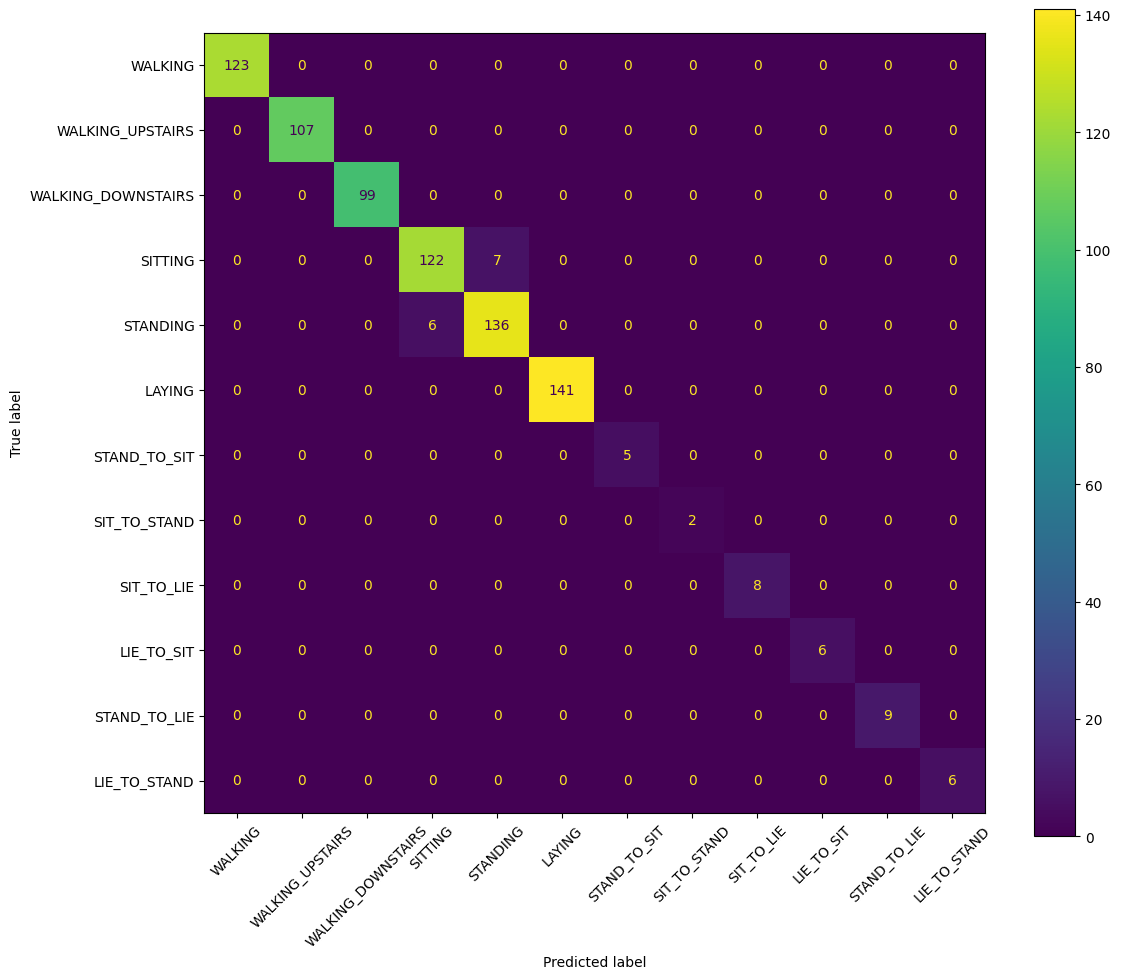

In [4]:
def compute_miou(cm):
    iou_per_class = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = tp + fp + fn
        iou_per_class.append(tp / denom if denom > 0 else 0.0)
    return np.mean(iou_per_class), iou_per_class

# In-sample validation (for reference only)
y_val_pred  = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)

val_acc = (y_val_pred == y_val).mean()
print(f"\nValidation Accuracy (in-sample): {val_acc:.4f}")
print(classification_report(y_val, y_val_pred, target_names=ACTIVITY_LABELS))

auc_roc = roc_auc_score(y_val, y_val_proba, multi_class="ovr", average="macro")
print(f"Validation Macro AUC-ROC: {auc_roc:.4f}")

cm = confusion_matrix(y_val, y_val_pred)
miou, _ = compute_miou(cm)
print(f"Validation MIoU: {miou:.4f}")

disp = ConfusionMatrixDisplay(cm, display_labels=ACTIVITY_LABELS)
_, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()

## Testing


Test Accuracy: 0.9292
                    precision    recall  f1-score   support

           WALKING       0.90      0.98      0.94       496
  WALKING_UPSTAIRS       0.93      0.89      0.91       471
WALKING_DOWNSTAIRS       0.99      0.93      0.96       420
           SITTING       0.94      0.86      0.90       508
          STANDING       0.89      0.95      0.92       556
            LAYING       1.00      1.00      1.00       545
      STAND_TO_SIT       0.77      0.87      0.82        23
      SIT_TO_STAND       0.83      1.00      0.91        10
        SIT_TO_LIE       0.72      0.81      0.76        32
        LIE_TO_SIT       0.71      0.68      0.69        25
      STAND_TO_LIE       0.74      0.76      0.75        49
      LIE_TO_STAND       0.71      0.63      0.67        27

          accuracy                           0.93      3162
         macro avg       0.85      0.86      0.85      3162
      weighted avg       0.93      0.93      0.93      3162

Test Macro AUC

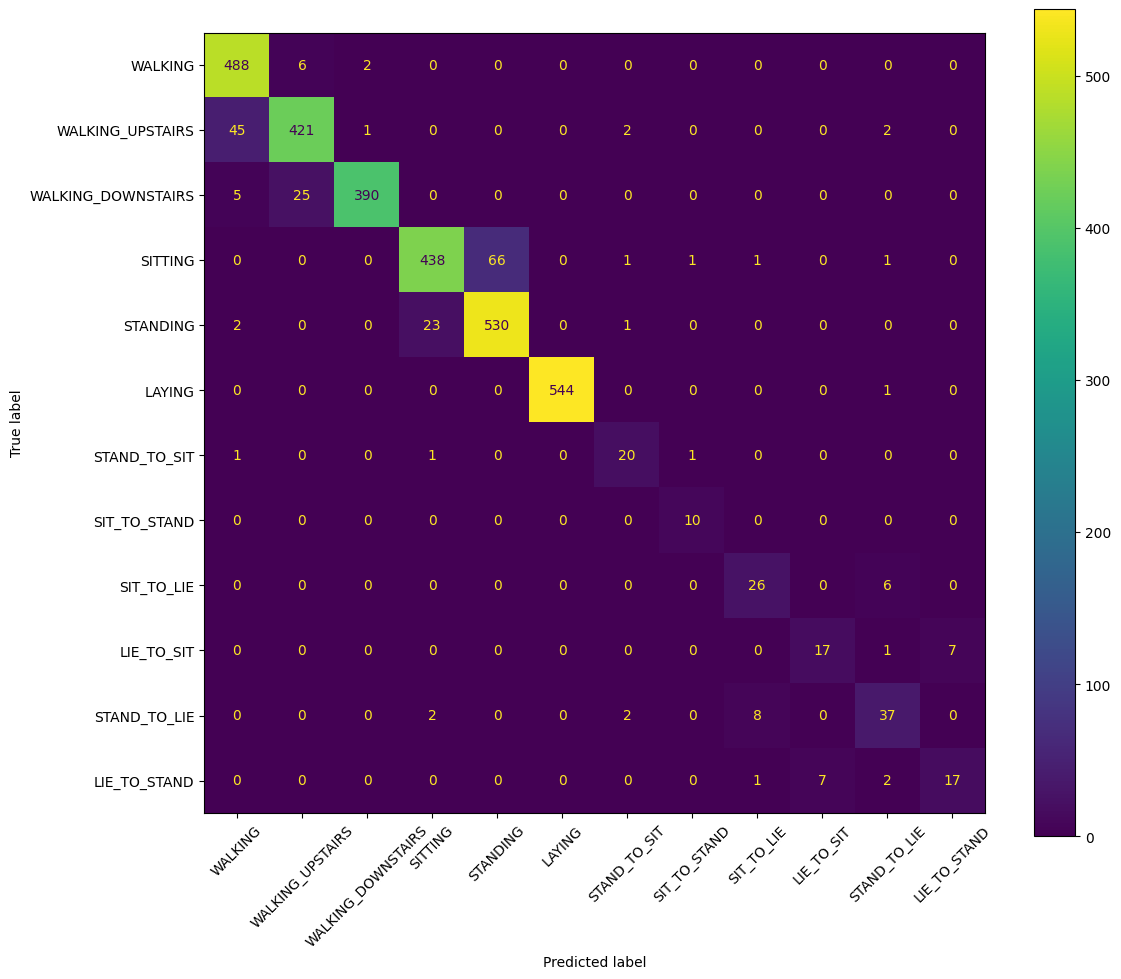

In [5]:
# Test evaluation — true out-of-sample result
y_test_pred  = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

test_acc = (y_test_pred == y_test).mean()
print(f"\nTest Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_test_pred, target_names=ACTIVITY_LABELS))

auc_roc = roc_auc_score(y_test, y_test_proba, multi_class="ovr", average="macro")
print(f"Test Macro AUC-ROC: {auc_roc:.4f}")

cm_test = confusion_matrix(y_test, y_test_pred)
miou_test, _ = compute_miou(cm_test)
print(f"Test MIoU: {miou_test:.4f}")

disp = ConfusionMatrixDisplay(cm_test, display_labels=ACTIVITY_LABELS)
_, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()